# 2.03 Calculating trace element concentrations with mineral-specific partition coefficients (Multi-lithology)

Simon Matthews (simonm@hi.is), February 2025

---

This notebook is intended to be a starting point for setting up calculations of magma trace element concentrations using mineral-specific partition coefficients combined with mineral proportions from a phase diagram. This template is for melting a mantle containing two lithologies.

Though I have added some description of each step, to find a more comprehensive account of why the calculation is structured the way it is see the pyMelt documentation and tutorials.

## 1. Preliminaries

First import the modules required:

In [1]:
import pyMelt as m
import numpy as np
import matplotlib.pyplot as plt

Then set up the lithology objects, in this case a lherzolite and a pyroxenite, then make a mantle from it:

In [2]:
lz = m.lithologies.matthews.klb1()
px = m.lithologies.matthews.kg1()
mantle = m.mantle([lz, px], 
                  [
                   0.95, # Proportion of lherzolite 
                   0.05, # Proportion of pyroxenite
                   ], 
                  ['lz', 'px'])

## 2. Melt the mantle

We will model melting at a typical mid-ocean ridge using a $T_p$ of 1350˚C.

In [3]:
column = mantle.adiabaticMelt(1350.0)

(<Figure size 640x480 with 2 Axes>,
 array([<AxesSubplot:xlabel='Temperature (°C)', ylabel='Pressure (GPa)'>,
        <AxesSubplot:xlabel='Melt Fraction'>], dtype=object))

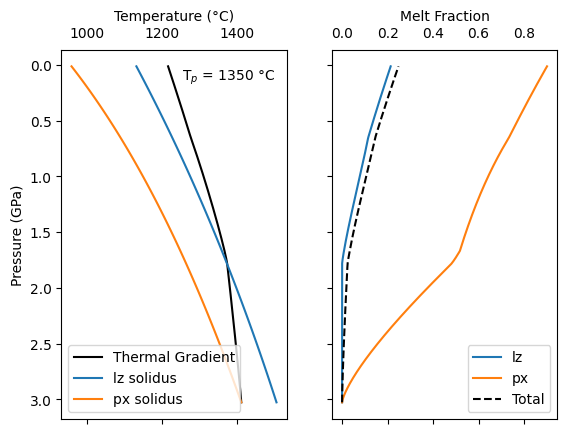

In [4]:
column.plot()

We need to know the mineral proportions at each step of melting:

In [5]:
column.calculateMineralProportions()

And we make a quick plot showing them:

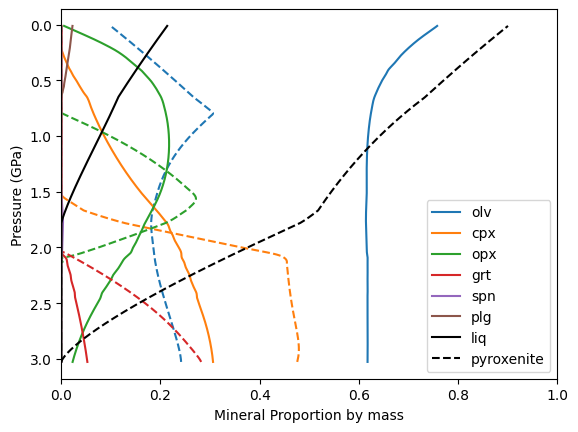

In [6]:
fig, ax = plt.subplots()

for i in range(len(column.mantle.lithologies[0].phaseDiagram.minerals)):
    mineral = column.mantle.lithologies[0].phaseDiagram.minerals[i]
    ax.plot(column.composition['lz'][mineral],
            column.composition['lz']['P'],
            label=mineral,
            c=f'C{i}')
    if mineral in column.mantle.lithologies[1].phaseDiagram.minerals:
        ax.plot(column.composition['px'][mineral],
            column.composition['px']['P'],
            c=f'C{i}', ls='--')


ax.plot(column.composition['lz']['F'],
        column.composition['lz']['P'],
        label='liq', c='k')

ax.plot(column.composition['px']['F'],
        column.composition['px']['P'],
        label='pyroxenite', c='k', ls='--')

ax.invert_yaxis()
ax.legend()

ax.set_xlim(0, 1.0)

ax.set_ylabel('Pressure (GPa)')
ax.set_xlabel('Mineral Proportion by mass')

plt.show()

## 3. Set up trace element calculation

The default partition coefficients for each mineral and trace element are shown below. Look at the FRTE tutorial for an example of setting your own partition coefficients.

In [7]:
m.chemistry.defaultD

,olv,cpx,opx,plg,grt,spn
Rb,0.000300,0.0004,0.000200,0.030,0.00020,0.0001
Ba,0.000005,0.0004,0.000006,0.330,0.00007,0.0001
Th,0.000050,0.0059,0.002000,0.050,0.00900,0.0000
U,0.000380,0.0094,0.002000,0.110,0.02800,0.0000
Nb,0.000500,0.0150,0.004000,0.010,0.01500,0.0000
Ta,0.000500,0.0150,0.004000,0.000,0.01500,0.0000
La,0.000500,0.0490,0.003100,0.270,0.00100,0.0100
Ce,0.000500,0.0800,0.004000,0.200,0.00500,0.0100
Pb,0.003000,0.0120,0.009000,0.360,0.00500,0.0000
Pr,0.000800,0.1260,0.004800,0.170,0.01400,0.0100


We must set the concentration of trace elements in the mantle source. This can be done either by supplying a pandas DataFrame, or by setting up nested dictionaries, as shown here. 

The concentrations assigned to the lherzolite are the "Average DMM" from Workman & Hart (2005).

The concentrations assigned to the pyroxenite are a 50:50 mixture of "Average DMM" from Workman & Hart (2005) and "Bulk Subducted Igneous Crust" from Stracke et al. (2003).

In [8]:
c0 = {
    # ==== LHERZOLITE C0 =====
    'lz': {
        'Rb': 0.05,
        'Ba': 0.563,
        'Th': 0.0079,
        'U':  0.0032,
        'Nb': 0.1485,
        'Ta': 0.0096,
        'La': 0.192,
        'Ce': 0.550,
        'Pb': 0.018,
        'Nd': 0.581,
        'Sr': 7.664,
        'Zr': 5.082,
        'Hf': 0.157,
        'Sm': 0.239,
        'Eu': 0.096,
        'Gd': 0.358,
        'Dy': 0.505,
        'Y':  3.328,
        'Er': 0.348,
        'Yb': 0.365,
        'Lu': 0.058,
        },
    # ==== PYROXENITE C0 =====
    'px': {
        'Rb': 0.31, 
        'Ba': 3.5765, 
        'Th': 0.04795, 
        'U': 0.0151, 
        'Nb': 1.04925, 
        'Ta': 0.0668, 
        'La': 0.936, 
        'Ce': 3.22, 
        'Pb': 0.054, 
        'Nd': 4.0155, 
        'Sr': 44.332, 
        'Zr': 34.541, 
        'Hf': 0.9685, 
        'Sm': 1.4645, 
        'Eu': 0.568, 
        'Gd': 2.194, 
        'Dy': 2.7575, 
        'Y': 15.914, 
        'Er': 1.739, 
        'Yb': 1.6775, 
        'Lu': 0.254
        }
}

## 4. Run the trace element calculation

Now we feed the mantle trace element concentrations into the calculation. We can also set a residual porosity during melting (by default it is set at 0.0):

In [9]:
column.calculateTraceElements(c0=c0,
                              porosity=0.005
                              )

We can plot the instantaneous melt compositions, for example:

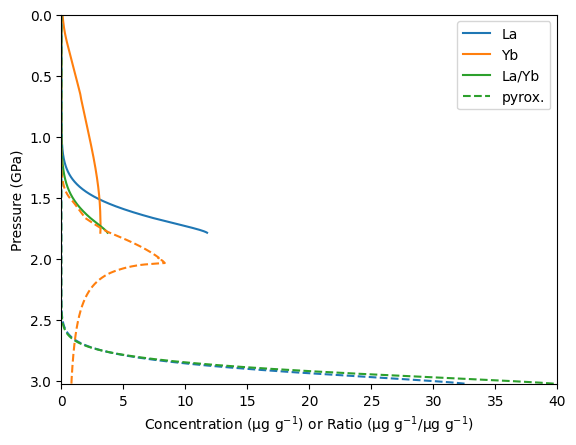

In [13]:
fig, ax = plt.subplots()

ax.plot(column.composition['lz'].liq_La, 
        column.P,
        label='La',c='C0')
ax.plot(column.composition['lz'].liq_Yb, 
        column.P,
        label='Yb',c='C1')
ax.plot(column.composition['lz'].liq_La/column.composition['lz'].liq_Yb, 
        column.P, 
        label='La/Yb',c='C2')

ax.plot(column.composition['px'].liq_La, 
        column.P,
        ls='--',c='C0')
ax.plot(column.composition['px'].liq_Yb, 
        column.P,
        ls='--',c='C1')
ax.plot(column.composition['px'].liq_La/column.composition['px'].liq_Yb, 
        column.P, 
        label='pyrox.',
        ls='--',c='C2')

ax.invert_yaxis()
ax.legend()
ax.set_xlim(0, 40)
ax.set_ylim(np.max(column.P), 0.0)

ax.set_xlabel('Concentration (µg g$^{-1}$) or Ratio (µg g$^{-1}$/µg g$^{-1}$)')

ax.set_ylabel('Pressure (GPa)')

plt.show()

We could also save them as a csv files:

In [ ]:
column.composition['lz'].to_csv('lz_te_concs.csv')
column.composition['px'].to_csv('px_te_concs.csv')

## 5. Calculate aggregate melt composition

Next we can calculate the concentrations in the aggregate melt. This requires making some assumptions about the melting region corresponding to the geodynamic setting. Here we assume we are melting at a mid-ocean ridge. Considering the high $T_p$ value used above, this might be representative of a location like Iceland.

For other geodynamic settings, see the code given in other templates.

In [14]:
mor = m.geosettings.spreadingCentre(column)

We can look at these melt concentrations by printing the result:

*note that this is a little indirect at the moment- I need to fix this*

In [15]:
for name, conc in mor.chemistry.iteritems():
    if name[:3] == 'liq':
        print(f'{name[4:]}: {conc:.3f}')

Rb: 0.523
Ba: 5.927
Th: 0.083
U: 0.031
Nb: 1.643
Ta: 0.106
La: 1.860
Ce: 5.513
Pb: 0.158
Nd: 5.773
Sr: 76.241
Zr: 51.344
Hf: 1.377
Sm: 2.108
Eu: 0.818
Gd: 3.056
Dy: 3.991
Y: 23.627
Er: 2.499
Yb: 2.454
Lu: 0.376


We can also plot a spider diagram:

(<Figure size 960x720 with 1 Axes>,
 <AxesSubplot:ylabel='Normalised concentration'>)

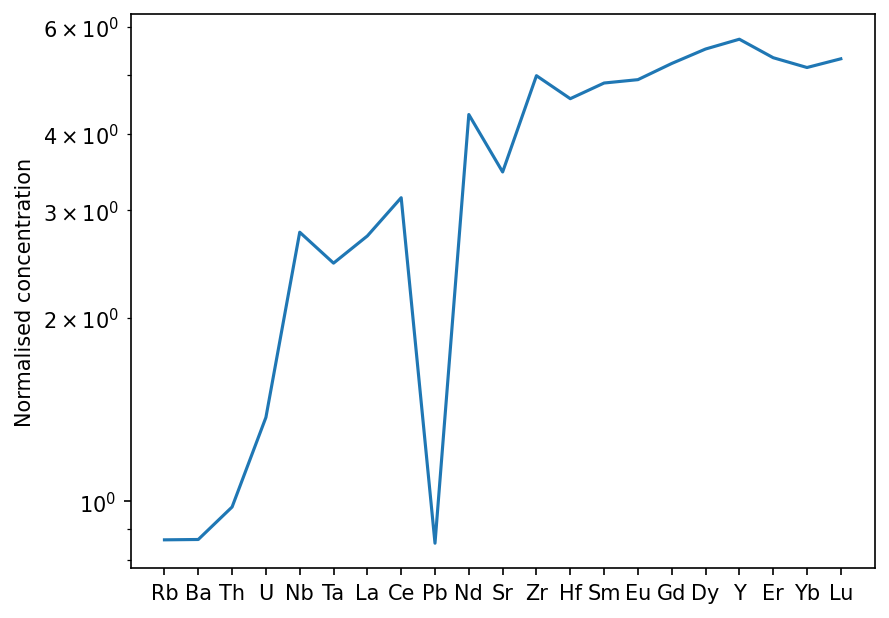

In [16]:
mor.plotSpider()

## 6. References

Workman, R. K., & Hart, S. R. (2005). Major and trace element composition of the depleted MORB mantle (DMM). Earth and Planetary Science Letters, 231(1-2), 53-72.

Stracke, A., Bizimis, M., & Salters, V. J. (2003). Recycling oceanic crust: Quantitative constraints. Geochemistry, Geophysics, Geosystems, 4(3).